# EXPERIMENT–3: Processing Data

## Objective
Perform text preprocessing and morphological analysis using a Kaggle dataset of IMDb movie reviews.

### Dataset
We use the **IMDb Dataset of 50K Movie Reviews**, containing review text and positive/negative sentiment labels. The Kaggle version has 50,000 reviews with two columns: `review` and `sentiment`. The dataset is a standard NLP benchmark. See the Kaggle dataset page for details.


## Experiment Tasks
1. Load a text dataset.
2. Perform basic preprocessing: HTML removal, lowercasing, punctuation/noise removal, tokenization, stop-word removal and lemmatization.
3. Compare original and processed text.
4. Perform morphological analysis using stemming, lemmatization and word-affix analysis.


In [ ]:
# Install required libraries if necessary
!pip install -q nltk pandas matplotlib seaborn kagglehub


In [ ]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk import pos_tag

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger_eng')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

## 1. Load the Kaggle Dataset

### Option A — KaggleHub (recommended)
The following cell downloads the Kaggle dataset directly. If Kaggle authentication is required in your environment, download the CSV from Kaggle and use Option B below.


In [ ]:
import kagglehub

# Download the Kaggle dataset
path = kagglehub.dataset_download('lakshmi25npathi/imdb-dataset-of-50k-movie-reviews')
print('Dataset path:', path)

# Find CSV file
csv_files = []
for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith('.csv'):
            csv_files.append(os.path.join(root, file))

print('CSV files found:', csv_files)
csv_path = csv_files[0]
df = pd.read_csv(csv_path)
df.head()


Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Dataset path: /kaggle/input/imdb-dataset-of-50k-movie-reviews
CSV files found: ['/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv']


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### Option B — If the CSV was downloaded manually
Place `IMDB Dataset.csv` in the same folder as this notebook and run the following cell instead.

In [ ]:
# df = pd.read_csv('IMDB Dataset.csv')
# df.head()


In [ ]:
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nMissing values:')
print(df.isnull().sum())

print('\nClass distribution:')
print(df['sentiment'].value_counts())


Shape: (50000, 2)

Columns: ['review', 'sentiment']

Missing values:
review       0
sentiment    0
dtype: int64

Class distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


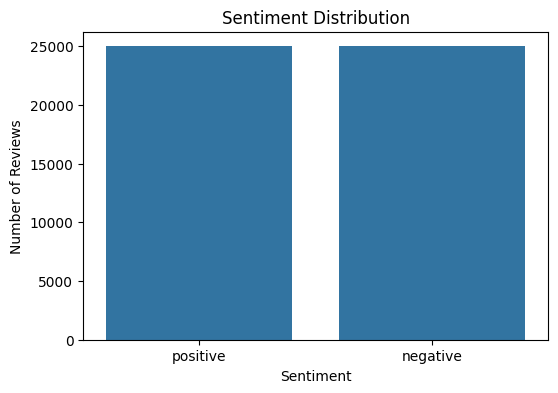

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='sentiment')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()


## 2. Inspect a Sample Review

In [ ]:
print('Original Review:\n')
print(df.loc[0, 'review'])
print('\nSentiment:', df.loc[0, 'sentiment'])


Original Review:

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show

## 3. Text Preprocessing

The preprocessing pipeline is:

**HTML removal → lowercase conversion → punctuation/noise removal → tokenization → stop-word removal → lemmatization**

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # Convert to lowercase
    text = text.lower()

    # Keep alphabetic characters and spaces
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['clean_text'] = df['review'].apply(clean_text)
df[['review', 'clean_text']].head()


,review,clean_text
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,basically there s a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei s love in the time of money is a...


## 4. Tokenization

In [ ]:
df['tokens'] = df['clean_text'].apply(word_tokenize)

print('Original text:')
print(df.loc[0, 'clean_text'])

print('\nTokens:')
print(df.loc[0, 'tokens'][:50])


Original text:
one of the other reviewers has mentioned that after watching just oz episode you ll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the word it is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda em city is home to many aryans muslims gangstas latinos christians italians irish and more so scuffles death stares dodgy dealings and shady agreements are never far away i would say the main appeal of the show is due to the fact that it goes where other shows wouldn t dare f

## 5. Stop-word Removal

In [ ]:
def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df['filtered_tokens'] = df['tokens'].apply(remove_stopwords)

print('Before stop-word removal:')
print(df.loc[0, 'tokens'][:50])

print('\nAfter stop-word removal:')
print(df.loc[0, 'filtered_tokens'][:50])


Before stop-word removal:
['one', 'of', 'the', 'other', 'reviewers', 'has', 'mentioned', 'that', 'after', 'watching', 'just', 'oz', 'episode', 'you', 'll', 'be', 'hooked', 'they', 'are', 'right', 'as', 'this', 'is', 'exactly', 'what', 'happened', 'with', 'me', 'the', 'first', 'thing', 'that', 'struck', 'me', 'about', 'oz', 'was', 'its', 'brutality', 'and', 'unflinching', 'scenes', 'of', 'violence', 'which', 'set', 'in', 'right', 'from', 'the']

After stop-word removal:
['one', 'reviewers', 'mentioned', 'watching', 'oz', 'episode', 'hooked', 'right', 'exactly', 'happened', 'first', 'thing', 'struck', 'oz', 'brutality', 'unflinching', 'scenes', 'violence', 'set', 'right', 'word', 'go', 'trust', 'show', 'faint', 'hearted', 'timid', 'show', 'pulls', 'punches', 'regards', 'drugs', 'sex', 'violence', 'hardcore', 'classic', 'use', 'word', 'called', 'oz', 'nickname', 'given', 'oswald', 'maximum', 'security', 'state', 'penitentary', 'focuses', 'mainly', 'emerald']


## 6. Lemmatization

Lemmatization maps a word to its dictionary/base form. POS information is used here so that verbs and nouns can be handled more appropriately.

In [ ]:
def get_wordnet_pos(word):
    tag = pos_tag([word])[0][1]
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    return wordnet.NOUN

def lemmatize_tokens(tokens):
    tagged = pos_tag(tokens)
    result = []
    for word, tag in tagged:
        if tag.startswith('J'):
            pos = wordnet.ADJ
        elif tag.startswith('V'):
            pos = wordnet.VERB
        elif tag.startswith('N'):
            pos = wordnet.NOUN
        elif tag.startswith('R'):
            pos = wordnet.ADV
        else:
            pos = wordnet.NOUN
        result.append(lemmatizer.lemmatize(word, pos=pos))
    return result

# Demonstration on the first 1,000 reviews to keep the lab notebook fast.
df_lab = df.head(1000).copy()
df_lab['lemmas'] = df_lab['filtered_tokens'].apply(lemmatize_tokens)
df_lab['processed_text'] = df_lab['lemmas'].apply(lambda x: ' '.join(x))

print('Original:')
print(df_lab.loc[0, 'review'])
print('\nProcessed:')
print(df_lab.loc[0, 'processed_text'])


Original:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due 

## 7. Complete Preprocessing Comparison

In [ ]:
comparison = df_lab[['review', 'clean_text', 'tokens', 'filtered_tokens', 'lemmas', 'processed_text', 'sentiment']].head(5)
pd.set_option('display.max_colwidth', 250)
comparison


,review,clean_text,tokens,filtered_tokens,lemmas,processed_text,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes...",one of the other reviewers has mentioned that after watching just oz episode you ll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its brutality and unflinching scenes of violence whi...,"[one, of, the, other, reviewers, has, mentioned, that, after, watching, just, oz, episode, you, ll, be, hooked, they, are, right, as, this, is, exactly, what, happened, with, me, the, first, thing, that, struck, me, about, oz, was, its, brutality...","[one, reviewers, mentioned, watching, oz, episode, hooked, right, exactly, happened, first, thing, struck, oz, brutality, unflinching, scenes, violence, set, right, word, go, trust, show, faint, hearted, timid, show, pulls, punches, regards, drug...","[one, reviewer, mention, watch, oz, episode, hook, right, exactly, happen, first, thing, strike, oz, brutality, unflinching, scene, violence, set, right, word, go, trust, show, faint, hearted, timid, show, pull, punch, regard, drug, sex, violence...",one reviewer mention watch oz episode hook right exactly happen first thing strike oz brutality unflinching scene violence set right word go trust show faint hearted timid show pull punch regard drug sex violence hardcore classic use word call oz...,positive
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well ch...",a wonderful little production the filming technique is very unassuming very old time bbc fashion and gives a comforting and sometimes discomforting sense of realism to the entire piece the actors are extremely well chosen michael sheen not only h...,"[a, wonderful, little, production, the, filming, technique, is, very, unassuming, very, old, time, bbc, fashion, and, gives, a, comforting, and, sometimes, discomforting, sense, of, realism, to, the, entire, piece, the, actors, are, extremely, we...","[wonderful, little, production, filming, technique, unassuming, old, time, bbc, fashion, gives, comforting, sometimes, discomforting, sense, realism, entire, piece, actors, extremely, well, chosen, michael, sheen, got, polari, voices, pat, truly,...","[wonderful, little, production, film, technique, unassuming, old, time, bbc, fashion, give, comfort, sometimes, discomforting, sense, realism, entire, piece, actor, extremely, well, choose, michael, sheen, get, polari, voice, pat, truly, see, sea...",wonderful little production film technique unassuming old time bbc fashion give comfort sometimes discomforting sense realism entire piece actor extremely well choose michael sheen get polari voice pat truly see seamless edit guided reference wil...,positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic, but the dialogue is witty and the characters are likable (even the w...",i thought this was a wonderful way to spend time on a too hot summer weekend sitting in the air conditioned theater and watching a light hearted comedy the plot is simplistic but the dialogue is witty and the characters are likable even the well ...,"[i, thought, this, was, a, wonderful, way, to, spend, time, on, a, too, hot, summer, weekend, sitting, in, the, air, conditioned, theater, and, watching, a, light, hearted, comedy, the, plot, is, simplistic, but, the, dialogue, is, witty, and, th...","[thought, wonderful, way, spend, time, hot, summer, weekend, sitting, air, conditioned, theater, watching, light, hearted, comedy, 

## 8. Morphological Analysis

**Morphology** studies the internal structure of words. A word can contain a root and affixes such as prefixes and suffixes.

Examples:

- `unhappiness` → `un + happy + ness`
- `replayed` → `re + play + ed`
- `students` → `student + s`
- `playing` → `play + ing`


In [ ]:
stemmer = PorterStemmer()

morph_words = [
    'playing', 'played', 'plays', 'studies', 'studying',
    'students', 'happiness', 'unhappiness', 'replayed', 'cars'
]

morph_df = pd.DataFrame({'word': morph_words})
morph_df['stem'] = morph_df['word'].apply(stemmer.stem)
morph_df['lemma'] = morph_df['word'].apply(lambda x: lemmatizer.lemmatize(x))

morph_df


,word,stem,lemma
0,playing,play,playing
1,played,play,played
2,plays,play,play
3,studies,studi,study
4,studying,studi,studying
5,students,student,student
6,happiness,happi,happiness
7,unhappiness,unhappi,unhappiness
8,replayed,replay,replayed
9,cars,car,car


### Prefix and suffix analysis

The following simple rule-based function identifies common English prefixes and suffixes. This is an educational morphological-analysis demonstration rather than a complete morphological parser.

In [ ]:
prefixes = ['un', 're', 'dis', 'in', 'im', 'pre', 'mis']
suffixes = ['ness', 'ment', 'ing', 'ed', 'ly', 'er', 'est', 's']

def analyze_affixes(word):
    found_prefix = ''
    found_suffix = ''
    root = word

    for p in sorted(prefixes, key=len, reverse=True):
        if root.startswith(p) and len(root) - len(p) >= 3:
            found_prefix = p
            root = root[len(p):]
            break

    for s in sorted(suffixes, key=len, reverse=True):
        if root.endswith(s) and len(root) - len(s) >= 3:
            found_suffix = s
            root = root[:-len(s)]
            break

    return pd.Series([found_prefix, root, found_suffix], index=['prefix', 'root', 'suffix'])

affix_df = morph_df[['word']].copy()
affix_df[['prefix', 'root', 'suffix']] = affix_df['word'].apply(analyze_affixes)
affix_df


,word,prefix,root,suffix
0,playing,,play,ing
1,played,,play,ed
2,plays,,play,s
3,studies,,studie,s
4,studying,,study,ing
5,students,,student,s
6,happiness,,happi,ness
7,unhappiness,un,happi,ness
8,replayed,re,play,ed
9,cars,,car,s


## 9. Morphological Analysis of Words from the Dataset

The next cell extracts frequent words from the processed IMDb reviews and compares their stem and lemma.

In [ ]:
from collections import Counter

all_words = []
for tokens in df_lab['filtered_tokens']:
    all_words.extend(tokens)

word_counts = Counter(all_words)
top_words = [word for word, count in word_counts.most_common(30)]

morph_dataset = pd.DataFrame({'word': top_words})
morph_dataset['frequency'] = morph_dataset['word'].map(word_counts)
morph_dataset['stem'] = morph_dataset['word'].apply(stemmer.stem)
morph_dataset['lemma'] = morph_dataset['word'].apply(lambda x: lemmatizer.lemmatize(x))

morph_dataset


,word,frequency,stem,lemma
0,movie,1788,movi,movie
1,film,1559,film,film
2,one,1007,one,one
3,like,804,like,like
4,good,540,good,good
5,even,527,even,even
6,see,525,see,see
7,would,497,would,would
8,story,462,stori,story
9,time,457,time,time


## 10. Number of Tokens Before and After Preprocessing

In [ ]:
df_lab['token_count'] = df_lab['tokens'].apply(len)
df_lab['filtered_count'] = df_lab['filtered_tokens'].apply(len)

print('Total tokens before stop-word removal:', df_lab['token_count'].sum())
print('Total tokens after stop-word removal:', df_lab['filtered_count'].sum())
print('Reduction:', df_lab['token_count'].sum() - df_lab['filtered_count'].sum())


Total tokens before stop-word removal: 234185
Total tokens after stop-word removal: 118390
Reduction: 115795


## 11. Save the Processed Dataset

Only the first 1,000 reviews are processed in the POS-aware lemmatization section to make the classroom notebook faster. The original 50K dataset remains available in `df`.

In [ ]:
output = df_lab[['review', 'sentiment', 'clean_text', 'processed_text']]
output.to_csv('IMDB_processed_1000.csv', index=False)
print('Saved as IMDB_processed_1000.csv')


Saved as IMDB_processed_1000.csv


## Result

The IMDb movie-review dataset was successfully loaded and processed. The experiment demonstrated text cleaning, tokenization, stop-word removal and lemmatization. Morphological analysis was demonstrated using stemming, lemmatization, and identification of prefixes, roots and suffixes.

### Conclusion
Text preprocessing converts raw natural-language text into a cleaner representation suitable for NLP algorithms. Morphological analysis provides information about the internal structure and formation of words and is useful in tasks such as information retrieval, POS tagging, text classification, machine translation and other NLP applications.

## Viva Questions

1. What is tokenization?
2. What are stop words?
3. What is the difference between stemming and lemmatization?
4. Why is lowercasing performed during preprocessing?
5. What is a morpheme?
6. What are free and bound morphemes?
7. What is a root word?
8. What is the difference between a prefix and suffix?
9. Why can stemming produce words that are not valid English words?
10. Why can POS information improve lemmatization?